# Simulasi Pengangkutan Sampah Desa
## Tugas Besar – Dasar Kecerdasan Artificial

**Algoritma Heuristik yang digunakan:**
- **Gerobak**: *Nearest Neighbor Heuristic* — selalu menuju rumah terdekat yang belum diambil  
- **Truk**: *Greedy Capacity Fill* — mengisi kapasitas dengan rumah-rumah terdekat per batch  
- **Transfer Gerobak→Truk**: *Cost-Benefit Analysis* — hitung waktu transfer vs pergi ke TPS  
- **Sharing sampah**: Satu rumah bisa diambil sebagian oleh beberapa gerobak/truk

In [97]:
import random
import math
from dataclasses import dataclass
from typing import List, Optional, Tuple

# CONST
SEED = 42

NUM_HOUSES = 100
GRID_SIZE = 50 # grid 50x50 satuan
NUM_TPS = 3

CAP_GEROBAK = 15 # kg
CAP_TRUK = 200 # kg
TPS_CAP_MIN = 400
TPS_CAP_MAX = 500

HOUSE_TRASH_MIN = 0
HOUSE_TRASH_MAX = 7

# Waktu operasi (menit sejak 00:00)
GEROBAK_START = 6 * 60 # 06:00
GEROBAK_END = 15 * 60 # 15:00
TRUK_START = 8 * 60 # 08:00
TRUK_END = 17 * 60 # 17:00

# Loading time
GEROBAK_LOAD_PER_KG = 2 # 2 menit/kg
TRUK_LOAD_PER_10KG = 2 # 2 menit per 10 kg

# Travel time
GEROBAK_TRAVEL_PER_DIST = 3 # 3 menit per 1 satuan jarak
TRUK_TRAVEL_PER_5DIST = 3 # 3 menit per 5 satuan jarak

print("Const ready")

Const ready


## Helper Func

In [98]:
# Konversi menit sejak 00:00 ke format HH:MM
def mins_to_hhmm(m: int) -> str:
    h = m // 60
    mn = m % 60
    return f"{h:02d}:{mn:02d}"

# Jarak Euclidean antara dua titik
def euclidean(a, b) -> float:
    return math.sqrt((a[0]-b[0])**2 + (a[1]-b[1])**2)

# Waktu tempuh gerobak: 3 menit per 1 satuan jarak
def gerobak_travel_time(dist: float) -> float:
    return dist * GEROBAK_TRAVEL_PER_DIST

# Waktu tempuh truk: 3 menit per 5 satuan jarak = 0.6 menit/satuan
def truk_travel_time(dist: float) -> float:
    return dist * (TRUK_TRAVEL_PER_5DIST / 5.0)

# Waktu loading gerobak: 2 menit per kg
def gerobak_load_time(kg: float) -> float:
    return kg * GEROBAK_LOAD_PER_KG

# Waktu loading truk: 2 menit per 10 kg
def truk_load_time(kg: float) -> float:
    return (kg / 10.0) * TRUK_LOAD_PER_10KG

print("Helper functions ready")

Helper functions ready


## Data Classes (House, TPS, LogEntry)

In [99]:
@dataclass
class House:
    id: int
    x: float
    y: float
    trash_initial: float
    trash_remaining: float = 0.0

    def __post_init__(self):
        self.trash_remaining = self.trash_initial


@dataclass
class TPS:
    id: int
    x: float
    y: float
    capacity: float
    stored: float = 0.0

    @property
    def available(self):
        return self.capacity - self.stored


@dataclass
class LogEntry:
    actor: str
    time: str
    event: str
    detail: str

    def __str__(self):
        return f"[{self.time}] {self.actor:<12} | {self.event:<20} | {self.detail}"

print("Data classes ready")

Data classes ready


## Agent Classes (Gerobak & Truk)

In [100]:
# Agen gerobak sampah
# Heuristik: Nearest Neighbor — selalu menuju rumah terdekat yang ada sampah
# Bisa transfer sampah ke truk jika lebih efisien daripada ke TPS
class Gerobak:
    def __init__(self, gid: int, start_pos: Tuple[float, float]):
        self.id = gid
        self.x, self.y = start_pos
        self.load = 0.0
        self.time = GEROBAK_START
        self.total_dist = 0.0
        self.total_time_travel = 0.0
        self.total_time_load = 0.0
        self.logs: List[LogEntry] = []
        self.active = True
        self.trips_to_tps = 0
        self.trips_to_truk = 0

    @property
    def pos(self): return (self.x, self.y)

    def name(self): return f"Gerobak-{self.id}"

    def log(self, event: str, detail: str):
        self.logs.append(LogEntry(
            actor=self.name(),
            time=mins_to_hhmm(int(self.time)),
            event=event, detail=detail))

    def move_to(self, tx, ty):
        dist = euclidean(self.pos, (tx, ty))
        travel = gerobak_travel_time(dist)
        self.x, self.y = tx, ty
        self.total_dist += dist
        self.total_time_travel += travel
        self.time += travel
        return dist, travel

    # Ambil sampah dari rumah (bisa sebagian — sharing support)
    def collect_from_house(self, house: 'House', kg: float):
        load_t = gerobak_load_time(kg)
        house.trash_remaining = max(0.0, house.trash_remaining - kg)
        self.load += kg
        self.total_time_load += load_t
        self.time += load_t
        self.log("AMBIL_SAMPAH",
            f"Rumah-{house.id} ({house.x:.1f},{house.y:.1f}) "
            f"ambil {kg:.2f}kg | sisa rumah {house.trash_remaining:.2f}kg "
            f"| muatan gerobak {self.load:.2f}kg")

    # Buang semua muatan ke TPS
    def dump_to_tps(self, tps: 'TPS'):
        kg = self.load
        load_t = gerobak_load_time(kg)
        tps.stored = min(tps.capacity, tps.stored + kg)
        self.total_time_load += load_t
        self.time += load_t
        self.log("BUANG_TPS",
            f"TPS-{tps.id} ({tps.x:.1f},{tps.y:.1f}) "
            f"buang {kg:.2f}kg | TPS {tps.stored:.1f}/{tps.capacity:.1f}kg")
        self.load = 0.0
        self.trips_to_tps += 1

    # Titipkan sebagian/seluruh muatan ke truk saat berpapasan
    def dump_to_truck(self, truk: 'Truk', kg: float):
        load_t = gerobak_load_time(kg)
        self.load = max(0.0, self.load - kg)
        self.total_time_load += load_t
        self.time += load_t
        self.log("TITIP_TRUK",
            f"Transfer {kg:.2f}kg ke {truk.name()} | "
            f"sisa di gerobak {self.load:.2f}kg")
        self.trips_to_truk += 1

# Agen truk sampah.
# Heuristik: Greedy Capacity Fill — ambil batch rumah terdekat sampai hampir penuh.
# Mulai dari TPS dan kembali ke TPS saat penuh.
class Truk:
    def __init__(self, tid: int, tps: 'TPS'):
        self.id = tid
        self.x, self.y = tps.x, tps.y
        self.home_tps = tps
        self.load = 0.0
        self.time = TRUK_START
        self.total_dist = 0.0
        self.total_time_travel = 0.0
        self.total_time_load = 0.0
        self.logs: List[LogEntry] = []
        self.active = True
        self.trips_to_tps = 0

    @property
    def pos(self): return (self.x, self.y)

    def name(self): return f"Truk-{self.id}"

    def log(self, event: str, detail: str):
        self.logs.append(LogEntry(
            actor=self.name(),
            time=mins_to_hhmm(int(self.time)),
            event=event, detail=detail))

    def move_to(self, tx, ty):
        dist = euclidean(self.pos, (tx, ty))
        travel = truk_travel_time(dist)
        self.x, self.y = tx, ty
        self.total_dist += dist
        self.total_time_travel += travel
        self.time += travel
        return dist, travel

    # Ambil sampah dari rumah
    def collect_from_house(self, house: 'House', kg: float):
        load_t = truk_load_time(kg)
        house.trash_remaining = max(0.0, house.trash_remaining - kg)
        self.load += kg
        self.total_time_load += load_t
        self.time += load_t
        self.log("AMBIL_SAMPAH",
            f"Rumah-{house.id} ({house.x:.1f},{house.y:.1f}) "
            f"ambil {kg:.2f}kg | sisa rumah {house.trash_remaining:.2f}kg "
            f"| muatan truk {self.load:.2f}kg")

    # Buang semua muatan ke TPS
    def dump_to_tps(self, tps: 'TPS'):
        kg = self.load
        load_t = truk_load_time(kg)
        tps.stored = min(tps.capacity, tps.stored + kg)
        self.total_time_load += load_t
        self.time += load_t
        self.log("BUANG_TPS",
            f"TPS-{tps.id} ({tps.x:.1f},{tps.y:.1f}) "
            f"buang {kg:.2f}kg | TPS {tps.stored:.1f}/{tps.capacity:.1f}kg")
        self.load = 0.0
        self.trips_to_tps += 1

    # Terima sampah dari gerobak saat berpapasan
    def receive_from_gerobak(self, gerobak: 'Gerobak', kg: float):
        load_t = truk_load_time(kg)
        self.load += kg
        self.total_time_load += load_t
        self.time += load_t
        self.log("TERIMA_GEROBAK",
            f"Terima {kg:.2f}kg dari {gerobak.name()} | "
            f"muatan truk {self.load:.2f}kg")

print("Agent classes ready")

Agent classes ready


## Func Generate Peta Desa

In [101]:
# Generate posisi rumah dan TPS secara acak
# Semua posisi (rumah maupun TPS) di-random di dalam grid
# Constraint: posisi TPS tidak boleh sama/bertumpuk dengan rumah
def generate_map():
    houses = []
    positions = set()

    # Generate posisi rumah secara random
    for i in range(NUM_HOUSES):
        while True:
            x = round(random.uniform(0, GRID_SIZE), 1)
            y = round(random.uniform(0, GRID_SIZE), 1)
            if (x, y) not in positions:
                positions.add((x, y))
                break
        trash = round(random.uniform(HOUSE_TRASH_MIN, HOUSE_TRASH_MAX), 2)
        houses.append(House(id=i+1, x=x, y=y, trash_initial=trash))

    # Generate posisi TPS secara random
    tps_list = []
    for i in range(NUM_TPS):
        while True:
            tx = round(random.uniform(0, GRID_SIZE), 1)
            ty = round(random.uniform(0, GRID_SIZE), 1)
            if (tx, ty) not in positions:
                positions.add((tx, ty))
                break
        cap = round(random.uniform(TPS_CAP_MIN, TPS_CAP_MAX), 1)
        tps_list.append(TPS(id=i+1, x=tx, y=ty, capacity=cap))

    return houses, tps_list

print("Func Generate Map Ready")

Func Generate Map Ready


## Inisialisasi Data

In [102]:
random.seed()

# Jumlah agen
NUM_GEROBAK = random.randint(5, 7)
NUM_TRUK = random.randint(2, 4)

# Peta: rumah + TPS
houses, tps_list = generate_map()

# Truk mulai dari TPS
truk_list: List[Truk] = []
for i in range(NUM_TRUK):
    home_tps = tps_list[i % NUM_TPS]
    truk_list.append(Truk(i+1, home_tps))

# Gerobak mulai dari titik random
gerobak_list: List[Gerobak] = []
for i in range(NUM_GEROBAK):
    sx = round(random.uniform(2, GRID_SIZE - 2), 1)
    sy = round(random.uniform(2, GRID_SIZE - 2), 1)
    gerobak_list.append(Gerobak(i+1, (sx, sy)))

# Snapshot koordinat awal untuk verifikasi konsistensi
_snapshot_houses = {h.id: (h.x, h.y) for h in houses}
_snapshot_tps = {t.id: (t.x, t.y) for t in tps_list}
_snapshot_gerobak = {g.id: (g.x, g.y) for g in gerobak_list}

# Tampilkan ringkasan
total_trash = sum(h.trash_initial for h in houses)
print(f"INISIALISASI DATA (SEED={SEED})")
print()
print(f"Jumlah gerobak: {NUM_GEROBAK}")
print(f"Jumlah truk: {NUM_TRUK}")
print(f"Jumlah TPS: {NUM_TPS}")
print(f"Jumlah rumah: {NUM_HOUSES}")
print(f"Total sampah: {total_trash:.2f} kg")
print(f"Rata-rata/rumah: {total_trash/NUM_HOUSES:.2f} kg")
print()
print("Lokasi TPS (random):")
for t in tps_list:
    print(f"TPS-{t.id}: ({t.x:.1f}, {t.y:.1f})  kap={t.capacity:.1f} kg")
print()
print("Posisi awal Gerobak (random):")
for g in gerobak_list:
    print(f"Gerobak-{g.id}: ({g.x:.1f}, {g.y:.1f})")
print()
print("Posisi awal Truk (dari TPS):")
for t in truk_list:
    print(f"Truk-{t.id}: ({t.x:.1f}, {t.y:.1f})  <- TPS-{t.home_tps.id}")

INISIALISASI DATA (SEED=42)

Jumlah gerobak: 6
Jumlah truk: 2
Jumlah TPS: 3
Jumlah rumah: 100
Total sampah: 325.84 kg
Rata-rata/rumah: 3.26 kg

Lokasi TPS (random):
TPS-1: (7.8, 39.0)  kap=499.7 kg
TPS-2: (9.2, 28.2)  kap=404.0 kg
TPS-3: (20.3, 22.8)  kap=409.5 kg

Posisi awal Gerobak (random):
Gerobak-1: (7.1, 26.3)
Gerobak-2: (18.1, 19.5)
Gerobak-3: (7.9, 2.1)
Gerobak-4: (28.3, 27.8)
Gerobak-5: (13.8, 37.4)
Gerobak-6: (18.4, 43.2)

Posisi awal Truk (dari TPS):
Truk-1: (7.8, 39.0)  <- TPS-1
Truk-2: (9.2, 28.2)  <- TPS-2


### Visualisasi Peta Penduduk

Verifikasi: 100 rumah, 3 TPS
Rumah-1: (47.7, 22.0) sampah=4.33kg
TPS-1: (7.8, 39.0) kap=499.7kg

Koordinat terverifikasi ...


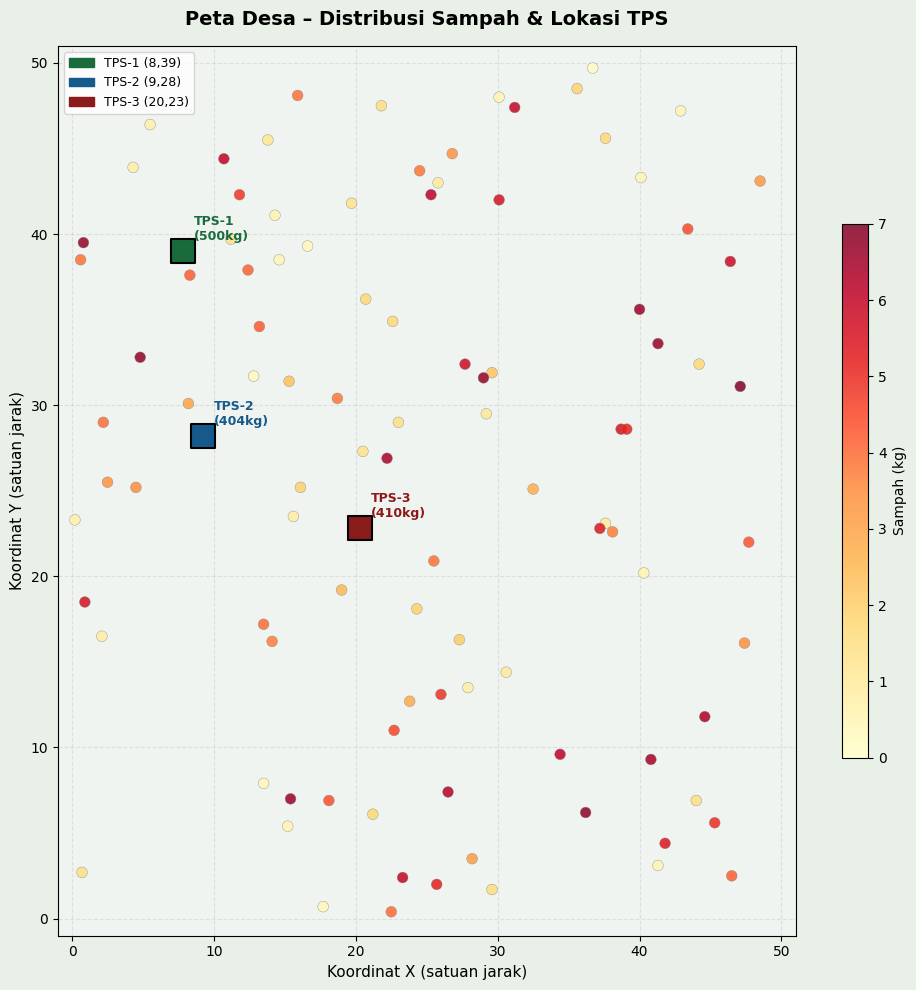

Peta saved


In [103]:
# Cek konsistensi koordinat
print(f"Verifikasi: {len(houses)} rumah, {len(tps_list)} TPS")
print(f"Rumah-1: ({houses[0].x:.1f}, {houses[0].y:.1f}) sampah={houses[0].trash_initial:.2f}kg")
print(f"TPS-1: ({tps_list[0].x:.1f}, {tps_list[0].y:.1f}) kap={tps_list[0].capacity:.1f}kg")
print()
assert all(_snapshot_houses[h.id] == (h.x, h.y) for h in houses), \
    "ERROR: Koordinat rumah berubah dari inisialisasi!"
assert all(_snapshot_tps[t.id] == (t.x, t.y) for t in tps_list), \
    "ERROR: Koordinat TPS berubah dari inisialisasi!"
print("Koordinat terverifikasi ...")

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(10, 10))
ax.set_xlim(-1, GRID_SIZE+1)
ax.set_ylim(-1, GRID_SIZE+1)
ax.set_facecolor('#f0f4f0')
fig.patch.set_facecolor('#e8f0e8')

# Plot rumah berdasarkan jumlah sampah
trash_vals = [h.trash_initial for h in houses]
hx = [h.x for h in houses]
hy = [h.y for h in houses]
sc = ax.scatter(hx, hy, c=trash_vals, cmap='YlOrRd', s=60, alpha=0.85, zorder=3, vmin=0, vmax=HOUSE_TRASH_MAX, edgecolors='gray', linewidths=0.3)
plt.colorbar(sc, ax=ax, label='Sampah (kg)', shrink=0.6)

# Plot TPS
tps_colors = ['#1a6b3c', '#155a8a', '#8b1a1a']
tps_labels = []
for i, tps in enumerate(tps_list):
    ax.scatter(tps.x, tps.y, c=tps_colors[i], s=300, marker='s', zorder=5, edgecolors='black', linewidths=1.5)
    ax.annotate(f'TPS-{tps.id}\n({tps.capacity:.0f}kg)', (tps.x, tps.y), textcoords="offset points", xytext=(8, 8), fontsize=9, fontweight='bold', color=tps_colors[i])
    tps_labels.append(mpatches.Patch(color=tps_colors[i], label=f'TPS-{tps.id} ({tps.x:.0f},{tps.y:.0f})'))

ax.set_title('Peta Desa – Distribusi Sampah & Lokasi TPS', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Koordinat X (satuan jarak)', fontsize=11)
ax.set_ylabel('Koordinat Y (satuan jarak)', fontsize=11)
ax.grid(True, alpha=0.3, linestyle='--')
ax.legend(handles=tps_labels, loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig('peta_desa.png', dpi=120, bbox_inches='tight')
plt.show()
print("Peta saved")

## Fungsi Heuristik

In [104]:
# Temukan TPS terdekat
def nearest_tps(pos: Tuple, tps_list: List[TPS], exclude_tps=None) -> Optional[TPS]:
    if exclude_tps is None: exclude_tps = set()
    candidates = [t for t in tps_list if t.id not in exclude_tps]
    if not candidates:
        return None
    return min(candidates, key=lambda t: euclidean(pos, (t.x, t.y)))

# Temukan rumah terdekat yang masih ada sampah
def nearest_house(pos: Tuple, houses: List[House]) -> Optional[House]:
    candidates = [h for h in houses if h.trash_remaining > 0.001]
    if not candidates:
        return None
    return min(candidates, key=lambda h: euclidean(pos, (h.x, h.y)))

print("Func heuristik ready")

Func heuristik ready


## Jalankan Simulasi

In [105]:
#  CEK KONSISTENSI — memastikan koordinat tidak berubah sejak cell Inisialisasi Data
errors = []
for hid, (x, y) in _snapshot_houses.items():
    h = next(h for h in houses if h.id == hid)
    if abs(h.x - x) > 1e-9 or abs(h.y - y) > 1e-9:
        errors.append(f"Rumah-{hid} berubah: ({x},{y}) → ({h.x},{h.y})")
for tid, (x, y) in _snapshot_tps.items():
    t = next(t for t in tps_list if t.id == tid)
    if abs(t.x - x) > 1e-9 or abs(t.y - y) > 1e-9:
        errors.append(f"TPS-{tid} berubah: ({x},{y}) → ({t.x},{t.y})")
for gid, (x, y) in _snapshot_gerobak.items():
    g = next(g for g in gerobak_list if g.id == gid)
    if abs(g.x - x) > 1e-9 or abs(g.y - y) > 1e-9:
        errors.append(f"Gerobak-{gid} berubah: ({x},{y}) → ({g.x},{g.y})")
if errors:
    print("Inkonsistensi koordinat detected:")
    for e in errors:
        print(f"{e}")
    raise RuntimeError("Simulasi dihentikan — koordinat tidak konsisten!")
else:
    print("Koordinat konsisten — semua posisi identik dengan inisialisasi")
# Reset log & trash sebelum simulasi
all_logs: List[LogEntry] = []
for h in houses:
    h.trash_remaining = h.trash_initial # reset sisa sampah ke kondisi awal hari ini
for t in tps_list:
    t.stored = 0.0 # reset TPS
for g in gerobak_list:
    g.load = 0.0; g.time = GEROBAK_START
    g.total_dist = 0.0; g.total_time_travel = 0.0; g.total_time_load = 0.0
    g.logs = []; g.trips_to_tps = 0; g.trips_to_truk = 0
    g.x, g.y = _snapshot_gerobak[g.id] # kembalikan ke posisi awal
for t in truk_list:
    t.load = 0.0; t.time = TRUK_START
    t.total_dist = 0.0; t.total_time_travel = 0.0; t.total_time_load = 0.0
    t.logs = []; t.trips_to_tps = 0
    t.x, t.y = _snapshot_tps[t.home_tps.id] # kembalikan ke TPS asal
total_trash_init = sum(h.trash_initial for h in houses)
print(f"Total sampah: {total_trash_init:.2f} kg")
print(f"Gerobak: {NUM_GEROBAK} unit")
print(f"Truk: {NUM_TRUK} unit")
print()
# Log mulai
for g in gerobak_list:
    g.log("MULAI", f"Posisi awal ({g.x:.1f},{g.y:.1f})")
for t in truk_list:
    t.log("MULAI", f"Mulai dari TPS-{t.home_tps.id} ({t.x:.1f},{t.y:.1f})")
print("Menjalankan simulasi concurrent (gerobak + truk) ...")
# Status selesai untuk tiap agen
gerobak_done = [False] * NUM_GEROBAK
truk_done = [False] * NUM_TRUK
iteration = 0
while not (all(gerobak_done) and all(truk_done)):
    iteration += 1
    if iteration > 500_000: # safety break
        print("Safety break!")
        break
    active_gerobak = [(i, g) for i, g in enumerate(gerobak_list) if not gerobak_done[i]]
    active_truk = [(i, t) for i, t in enumerate(truk_list) if not truk_done[i]]
    candidates = [("g", i, a) for i, a in active_gerobak] + [("t", i, a) for i, a in active_truk]
    if not candidates:
        break
    agent_type, idx, agent = min(candidates, key=lambda x: x[2].time)
    if agent_type == "g":
        g = agent
        if g.time >= GEROBAK_END:
            gerobak_done[idx] = True
            g.log("SELESAI_WAKTU", f"Operasi selesai {mins_to_hhmm(GEROBAK_END)} | sisa muatan {g.load:.2f}kg | jarak total {g.total_dist:.2f}")
            continue
        if g.load >= CAP_GEROBAK * 0.9:
            # ==========================================
            # RENDEZVOUS SAAT GEROBAK PENUH
            # ==========================================
            best_truk = None
            best_dist = float('inf')
            for t in truk_list:
                if t.time >= TRUK_END:
                    continue  
                d = euclidean(g.pos, t.pos)
                selisih_waktu = abs(t.time - g.time)
                can_accept = CAP_TRUK - t.load
                if selisih_waktu <= 30 and d <= 15.0 and can_accept >= 5.0:
                    if d < best_dist:
                        best_dist = d
                        best_truk = t
            if best_truk:
                g.move_to(best_truk.x, best_truk.y)
                if g.time >= GEROBAK_END:
                    gerobak_done[idx] = True
                    g.log("SELESAI_WAKTU", "Waktu habis saat menuju truk")
                    continue
                if best_truk.time < g.time:
                    best_truk.time = g.time
                transfer_kg = min(g.load, CAP_TRUK - best_truk.load)
                g.dump_to_truck(best_truk, transfer_kg)
                best_truk.receive_from_gerobak(g, transfer_kg)
                continue
            # Tidak ada truk yang cocok -> buang ke TPS
            visited_tps = set()
            while True:
                tps = nearest_tps(g.pos, tps_list, visited_tps)
                if not tps:
                    gerobak_done[idx] = True
                    g.log("ERROR", "Semua TPS penuh!")
                    break
                g.move_to(tps.x, tps.y)
                if g.time >= GEROBAK_END:
                    gerobak_done[idx] = True
                    g.log("SELESAI_WAKTU", "Waktu habis saat menuju TPS")
                    break
                if tps.stored >= tps.capacity * 0.99:
                    visited_tps.add(tps.id)
                    continue
                g.dump_to_tps(tps)
                break
            continue
        house = nearest_house(g.pos, houses)
        if house is None:
            if g.load > 0.001:
                visited_tps = set()
                while True:
                    tps = nearest_tps(g.pos, tps_list, visited_tps)
                    if not tps: break
                    g.move_to(tps.x, tps.y)
                    if g.time >= GEROBAK_END: break
                    if tps.stored >= tps.capacity * 0.99:
                        visited_tps.add(tps.id)
                        continue
                    g.dump_to_tps(tps)
                    break
            gerobak_done[idx] = True
            g.log("SELESAI_SAMPAH", f"Tidak ada sampah tersisa | jarak {g.total_dist:.2f} | waktu {g.time - GEROBAK_START:.0f} menit")
            continue
        g.move_to(house.x, house.y)
        if g.time >= GEROBAK_END:
            gerobak_done[idx] = True
            g.log("SELESAI_WAKTU", f"Waktu habis di jalan ke Rumah-{house.id}")
            continue
        space = CAP_GEROBAK - g.load
        take = min(house.trash_remaining, space)
        if take > 0.001:
            g.collect_from_house(house, take)
        if g.time >= GEROBAK_END:
            gerobak_done[idx] = True
            g.log("SELESAI_WAKTU", "Waktu habis saat loading")
            continue
        # ==========================================
        # RENDEZVOUS DI JALAN (PAPASAN)
        # ==========================================
        for t in truk_list:
            if t.time >= TRUK_END:
                continue
            d = euclidean(g.pos, t.pos)
            selisih_waktu = abs(t.time - g.time)
            if selisih_waktu <= 30 and d <= 15.0 and g.load >= 3.0:
                can_accept = CAP_TRUK - t.load
                if can_accept >= 5.0:
                    g.move_to(t.x, t.y)
                    if g.time >= GEROBAK_END:
                        gerobak_done[idx] = True
                        break
                    if t.time < g.time:
                        t.time = g.time
                    transfer_kg = min(g.load, can_accept)
                    g.dump_to_truck(t, transfer_kg)
                    t.receive_from_gerobak(g, transfer_kg)
                    break
    elif agent_type == "t":
        t = agent
        if t.time < TRUK_START:
            t.time = TRUK_START
            continue
        if t.time >= TRUK_END:
            truk_done[idx] = True
            t.log("SELESAI_WAKTU", f"Operasi selesai {mins_to_hhmm(TRUK_END)} | sisa muatan {t.load:.2f}kg | jarak total {t.total_dist:.2f}")
            continue
        if t.load >= CAP_TRUK * 0.9:
            visited_tps = set()
            while True:
                tps = nearest_tps(t.pos, tps_list, visited_tps)
                if not tps:
                    truk_done[idx] = True
                    t.log("ERROR", "Semua TPS penuh!")
                    break
                t.move_to(tps.x, tps.y)
                if t.time >= TRUK_END:
                    truk_done[idx] = True
                    t.log("SELESAI_WAKTU", "Waktu habis saat menuju TPS")
                    break
                if tps.stored >= tps.capacity * 0.99:
                    visited_tps.add(tps.id)
                    continue
                t.dump_to_tps(tps)
                break
            continue
        # Truk sekarang mengambil sampah seperti gerobak (nearest neighbor, bukan greedy batch)
        house = nearest_house(t.pos, houses)
        if house is None:
            if t.load > 0.001:
                visited_tps = set()
                while True:
                    tps = nearest_tps(t.pos, tps_list, visited_tps)
                    if not tps: break
                    t.move_to(tps.x, tps.y)
                    if t.time >= TRUK_END: break
                    if tps.stored >= tps.capacity * 0.99:
                        visited_tps.add(tps.id)
                        continue
                    t.dump_to_tps(tps)
                    break
            truk_done[idx] = True
            t.log("SELESAI_SAMPAH", f"Tidak ada sampah tersisa | jarak {t.total_dist:.2f}")
            continue
        t.move_to(house.x, house.y)
        if t.time >= TRUK_END:
            truk_done[idx] = True
            t.log("SELESAI_WAKTU", f"Waktu habis menuju Rumah-{house.id}")
            continue
        actual = min(house.trash_remaining, CAP_TRUK - t.load)
        if actual > 0.001:
            t.collect_from_house(house, actual)
all_logs = []
for g in gerobak_list:
    all_logs.extend(g.logs)
for t in truk_list:
    all_logs.extend(t.logs)
waktu_selesai_gerobak = max((min(g.time, GEROBAK_END) for g in gerobak_list), default=GEROBAK_END)
waktu_selesai_truk = max((min(t.time, TRUK_END) for t in truk_list), default=TRUK_END)
waktu_selesai_semua = max(waktu_selesai_gerobak, waktu_selesai_truk)
print(f"Simulasi concurrent selesai ({iteration} iterasi)")
print(f"Total event tercatat: {len(all_logs)}")
rumah_selesai = sum(1 for h in houses if h.trash_remaining < 0.001)
rumah_belum = NUM_HOUSES - rumah_selesai
print(f"\nSeluruh operasi selesai pada: {mins_to_hhmm(int(waktu_selesai_semua))}")
print(f"Sisa Rumah (belum terambil): {rumah_belum} rumah")
print(f"Sisa Rumah (terambil): {rumah_selesai}/{NUM_HOUSES} completed")



Koordinat konsisten — semua posisi identik dengan inisialisasi
Total sampah: 325.84 kg
Gerobak: 6 unit
Truk: 2 unit

Menjalankan simulasi concurrent (gerobak + truk) ...
Simulasi concurrent selesai (119 iterasi)
Total event tercatat: 141

Seluruh operasi selesai pada: 12:52
Sisa Rumah (belum terambil): 0 rumah
Sisa Rumah (terambil): 100/100 completed


## Laporan Hasil Simulasi

In [106]:
# Tampilkan menit dalam format Xj Ym
def mins_to_display(m: float) -> str:
    m = int(m)
    return f"{m//60}j {m%60}m" if m >= 60 else f"{m}m"

def bar_chart(val, total, width=20) -> str:
    filled = int(val / total * width) if total > 0 else 0
    return '█' * filled + '░' * (width - filled)

# Laporan Truk
print(f"LAPORAN TRUK SAMPAH")
print()
total_dist_truk = 0
total_trash_truk_dumped = 0

for t in truk_list:
    dumped = sum(
        float(l.detail.split("buang ")[1].split("kg")[0])
        for l in t.logs if "BUANG_TPS" in l.event
    ) if any("BUANG_TPS" in l.event for l in t.logs) else 0

    end_time = min(int(t.time), TRUK_END)
    op_time  = end_time - TRUK_START

    print(f"\n{t.name()}")
    print(f"Jarak tempuh: {t.total_dist:.2f} satuan jarak")
    print(f"Waktu perjalanan: {t.total_time_travel:.1f} menit")
    print(f"Waktu loading: {t.total_time_load:.1f} menit")
    print(f"Total waktu operasi: {op_time:.0f} menit " f"({mins_to_hhmm(TRUK_START)} – {mins_to_hhmm(end_time)})")
    print(f"Trip ke TPS: {t.trips_to_tps}")
    print(f"Sampah dibuang ke TPS: {dumped:.2f} kg")
    print(f"Sisa di truk: {t.load:.2f} kg")
    total_dist_truk += t.total_dist
    total_trash_truk_dumped += dumped

print(f"\nTotal jarak semua truk: {total_dist_truk:.2f} satuan jarak")
print(f"Total sampah ke TPS: {total_trash_truk_dumped:.2f} kg")

# Laporan Gerobak
print(f"LAPORAN GEROBAK SAMPAH")
print()
total_dist_gerobak = 0
total_trash_gerobak = 0

for g in gerobak_list:
    dumped = sum(
        float(l.detail.split("buang ")[1].split("kg")[0])
        for l in g.logs if "BUANG_TPS" in l.event
    ) if any("BUANG_TPS" in l.event for l in g.logs) else 0

    transferred = sum(
        float(l.detail.split("Transfer ")[1].split("kg")[0])
        for l in g.logs if "TITIP_TRUK" in l.event
    ) if any("TITIP_TRUK" in l.event for l in g.logs) else 0

    end_time = min(int(g.time), GEROBAK_END)
    op_time  = end_time - GEROBAK_START

    print(f"\n{g.name()}")
    print(f"Jarak tempuh: {g.total_dist:.2f} satuan jarak")
    print(f"Waktu perjalanan: {g.total_time_travel:.1f} menit")
    print(f"Waktu loading: {g.total_time_load:.1f} menit")
    print(f"Total waktu operasi: {op_time:.0f} menit " f"({mins_to_hhmm(GEROBAK_START)} – {mins_to_hhmm(end_time)})")
    print(f"Trip ke TPS: {g.trips_to_tps}")
    print(f"Trip ke Truk: {g.trips_to_truk}")
    print(f"Sampah ke TPS: {dumped:.2f} kg")
    print(f"Sampah titip ke Truk: {transferred:.2f} kg")
    print(f"Sisa di gerobak: {g.load:.2f} kg")
    total_dist_gerobak += g.total_dist
    total_trash_gerobak += dumped + transferred

print(f"\nTotal jarak semua gerobak: {total_dist_gerobak:.2f} satuan jarak")
print(f"Total sampah terangkut: {total_trash_gerobak:.2f} kg")

# Status TPS
print(f"STATUS TPS")
print()
total_tps = 0
for tps in tps_list:
    pct = tps.stored / tps.capacity * 100 if tps.capacity > 0 else 0
    bar = bar_chart(tps.stored, tps.capacity)
    print(f"\nTPS-{tps.id} ({tps.x:.0f},{tps.y:.0f})")
    print(f"Kapasitas: {tps.capacity:.1f} kg")
    print(f"Tersimpan: {tps.stored:.2f} kg [{bar}] {pct:.1f}%")
    print(f"Sisa ruang: {tps.available:.2f} kg")
    total_tps += tps.stored

# Sisa Sampah Rumah
print(f"SISA SAMPAH RUMAH TANGGA")
print()
remaining_houses = [h for h in houses if h.trash_remaining > 0.001]
total_remaining = sum(h.trash_remaining for h in houses)
print(f"Rumah masih ada sampah: {len(remaining_houses)} dari {NUM_HOUSES}")
print(f"Total sisa: {total_remaining:.2f} kg")
if remaining_houses:
    top5 = sorted(remaining_houses, key=lambda x: -x.trash_remaining)[:5]
    print(f"Top 5 rumah dengan sisa terbanyak:")
    for h in top5:
        print(f"Rumah-{h.id:3d}: {h.trash_remaining:.2f} kg " f"(dari {h.trash_initial:.2f} kg) di ({h.x:.1f},{h.y:.1f})")

# Ringkasan
print(f"RINGKASAN AKHIR")
print()
sisa_gerobak = sum(g.load for g in gerobak_list)
sisa_truk = sum(t.load for t in truk_list)
total_init = sum(h.trash_initial for h in houses)

print(f"Total sampah awal: {total_init:.2f} kg")
print(f"Di TPS (sudah dibuang): {total_tps:.2f} kg")
print(f"Masih di gerobak: {sisa_gerobak:.2f} kg (waktu habis)")
print(f"Masih di truk: {sisa_truk:.2f} kg (waktu habis)")
print(f"Sisa di rumah tangga: {total_remaining:.2f} kg")
accounted = total_tps + sisa_gerobak + sisa_truk + total_remaining
print(f"Total terakuntansi: {accounted:.2f} kg")
eff = total_tps / total_init * 100 if total_init > 0 else 0
print(f"\nEfisiensi ke TPS: {eff:.1f}%")
collected_pct = (total_tps + sisa_gerobak + sisa_truk) / total_init * 100 if total_init > 0 else 0
print(f"Sampah berhasil diangkut: {collected_pct:.1f}%")
selisih = abs(accounted - total_init)
assert selisih <= 0.001, (
    f"Neraca sampah tidak seimbang! "
    f"total_init={total_init:.2f}, terakuntansi={accounted:.2f}, "
    f"selisih={selisih:.4f} kg"
)

LAPORAN TRUK SAMPAH


Truk-1
Jarak tempuh: 83.97 satuan jarak
Waktu perjalanan: 50.4 menit
Waktu loading: 20.5 menit
Total waktu operasi: 173 menit (08:00 – 10:53)
Trip ke TPS: 1
Sampah dibuang ke TPS: 51.16 kg
Sisa di truk: 0.00 kg

Truk-2
Jarak tempuh: 217.66 satuan jarak
Waktu perjalanan: 130.6 menit
Waktu loading: 61.3 menit
Total waktu operasi: 191 menit (08:00 – 11:11)
Trip ke TPS: 1
Sampah dibuang ke TPS: 153.15 kg
Sisa di truk: 0.00 kg

Total jarak semua truk: 301.63 satuan jarak
Total sampah ke TPS: 204.31 kg
LAPORAN GEROBAK SAMPAH


Gerobak-1
Jarak tempuh: 104.12 satuan jarak
Waktu perjalanan: 312.4 menit
Waktu loading: 100.0 menit
Total waktu operasi: 412 menit (06:00 – 12:52)
Trip ke TPS: 2
Trip ke Truk: 0
Sampah ke TPS: 24.99 kg
Sampah titip ke Truk: 0.00 kg
Sisa di gerobak: 0.00 kg

Gerobak-2
Jarak tempuh: 98.81 satuan jarak
Waktu perjalanan: 296.4 menit
Waktu loading: 80.0 menit
Total waktu operasi: 376 menit (06:00 – 12:16)
Trip ke TPS: 2
Trip ke Truk: 1
Sampah ke TPS: 

## Report Pergerakan Sampah

In [107]:
def time_val(log: LogEntry) -> int:
    h, m = log.time.split(':')
    return int(h)*60 + int(m)

sorted_logs = sorted(all_logs, key=time_val)

print(f"REPORT PERGERAKAN SAMPAH (KRONOLOGI)")
print()
print(f"Total event: {len(sorted_logs)}")
print()

# Print per aktor
for actor_name in ([f"Gerobak-{g.id}" for g in gerobak_list] + [f"Truk-{t.id}" for t in truk_list]):
    actor_logs = [l for l in all_logs if l.actor == actor_name]
    if not actor_logs:
        continue
    print(f"[{actor_name}] – {len(actor_logs)} events")
    print(f"{'─'*62}")
    for log in actor_logs:
        print(f"{log.time}  {log.event:<22} {log.detail[:48]}")
    print()

# Kronologi gabungan (semua event)
print(f"KRONOLOGI GABUNGAN")
print()
print(f"{'Waktu':<7} {'Aktor':<12} {'Event':<22} {'Detail':<30}")
print(f"{'─'*67}")
for log in sorted_logs:
    print(f"{log.time:<7} {log.actor:<12} {log.event:<22} {log.detail[:30]}")
print()
print(f"Total kejadian transfer : {sum(1 for l in all_logs if l.event == 'TITIP_TRUK')} kali")
print(f"Total sampah ditransfer : {sum(float(l.detail.split('Transfer ')[1].split('kg')[0]) for l in all_logs if l.event == 'TITIP_TRUK'):.2f} kg")



REPORT PERGERAKAN SAMPAH (KRONOLOGI)

Total event: 141

[Gerobak-1] – 14 events
──────────────────────────────────────────────────────────────
06:00  MULAI                  Posisi awal (7.1,26.3)
06:15  AMBIL_SAMPAH           Rumah-84 (4.5,25.2) ambil 3.48kg | sisa rumah 0.
06:28  AMBIL_SAMPAH           Rumah-55 (2.5,25.5) ambil 3.38kg | sisa rumah 0.
06:39  AMBIL_SAMPAH           Rumah-16 (0.2,23.3) ambil 0.66kg | sisa rumah 0.
07:04  AMBIL_SAMPAH           Rumah-49 (0.9,18.5) ambil 5.60kg | sisa rumah 0.
07:13  AMBIL_SAMPAH           Rumah-82 (2.1,16.5) ambil 0.80kg | sisa rumah 0.
08:22  BUANG_TPS              TPS-2 (9.2,28.2) buang 13.92kg | TPS 13.9/404.0k
08:48  AMBIL_SAMPAH           Rumah-99 (16.1,25.2) ambil 1.94kg | sisa rumah 0
09:15  AMBIL_SAMPAH           Rumah-43 (23.0,29.0) ambil 1.41kg | sisa rumah 0
09:51  AMBIL_SAMPAH           Rumah-13 (32.5,25.1) ambil 2.72kg | sisa rumah 0
10:26  AMBIL_SAMPAH           Rumah-32 (30.6,14.4) ambil 1.02kg | sisa rumah 0
11:22  AMBIL_S

## Visualisasi Hasil

Koordinat konsisten


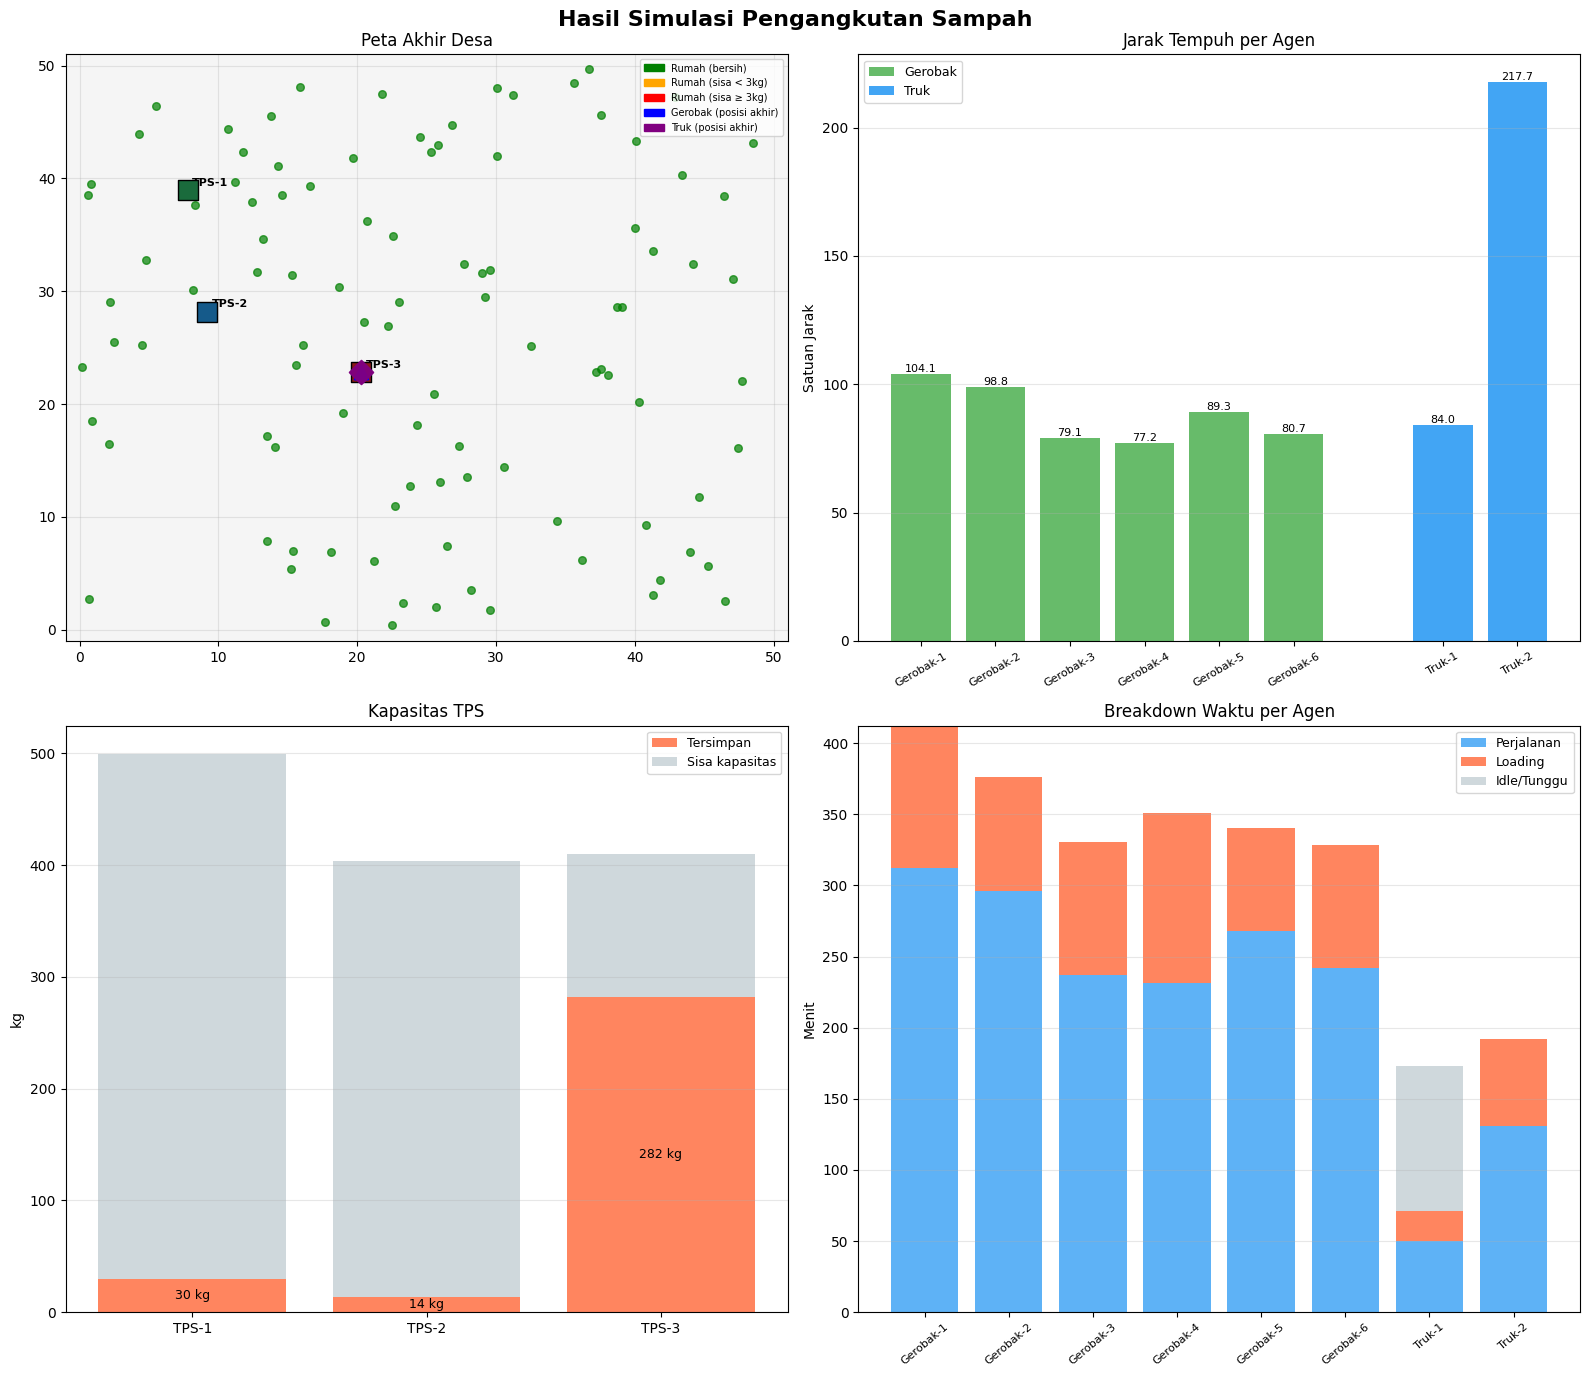

Grafik saved


In [108]:
# Cek konsistensi koordinat
vis_errors = []
for hid, (sx, sy) in _snapshot_houses.items():
    h = next(h for h in houses if h.id == hid)
    if abs(h.x - sx) > 1e-9 or abs(h.y - sy) > 1e-9:
        vis_errors.append(f"Rumah-{hid}: snapshot({sx},{sy}) != plot({h.x},{h.y})")
for tid, (sx, sy) in _snapshot_tps.items():
    t = next(t for t in tps_list if t.id == tid)
    if abs(t.x - sx) > 1e-9 or abs(t.y - sy) > 1e-9:
        vis_errors.append(f"TPS-{tid}: snapshot({sx},{sy}) != plot({t.x},{t.y})")
if vis_errors:
    print("Koordinat tidak konsisten")
    for e in vis_errors: print(f"{e}")
else:
    print("Koordinat konsisten")

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(16, 14))
fig.suptitle('Hasil Simulasi Pengangkutan Sampah', fontsize=16, fontweight='bold', y=0.98)

# Plot 1: Peta Akhir
ax = axes[0, 0]
ax.set_facecolor('#f5f5f5')
# Rumah: warna berdasarkan sisa sampah
for h in houses:
    color = 'green' if h.trash_remaining < 0.1 else ('orange' if h.trash_remaining < 3 else 'red')
    ax.scatter(h.x, h.y, c=color, s=30, alpha=0.7, zorder=2)
# TPS
tps_colors = ['#1a6b3c', '#155a8a', '#8b1a1a']
for i, tps in enumerate(tps_list):
    ax.scatter(tps.x, tps.y, c=tps_colors[i], s=200, marker='s', zorder=5, edgecolors='black')
    ax.annotate(f'TPS-{tps.id}', (tps.x, tps.y), xytext=(3,3), textcoords='offset points', fontsize=8, fontweight='bold')
# Posisi akhir gerobak & truk
for g in gerobak_list:
    ax.scatter(g.x, g.y, c='blue', s=100, marker='^', zorder=6, alpha=0.8)
for t in truk_list:
    ax.scatter(t.x, t.y, c='purple', s=150, marker='D', zorder=6, alpha=0.8)
legend_handles = [
    mpatches.Patch(color='green', label='Rumah (bersih)'),
    mpatches.Patch(color='orange', label='Rumah (sisa < 3kg)'),
    mpatches.Patch(color='red', label='Rumah (sisa ≥ 3kg)'),
    mpatches.Patch(color='blue', label='Gerobak (posisi akhir)'),
    mpatches.Patch(color='purple', label='Truk (posisi akhir)'),
]
ax.legend(handles=legend_handles, fontsize=7, loc='upper right')
ax.set_title('Peta Akhir Desa')
ax.set_xlim(-1, GRID_SIZE+1); ax.set_ylim(-1, GRID_SIZE+1)
ax.grid(True, alpha=0.3)

# Plot 2: Jarak Tempuh
ax = axes[0, 1]
names_g = [g.name() for g in gerobak_list]
dists_g = [g.total_dist for g in gerobak_list]
names_t = [t.name() for t in truk_list]
dists_t = [t.total_dist for t in truk_list]
x_g = np.arange(len(names_g))
x_t = np.arange(len(names_t)) + len(names_g) + 1
bars_g = ax.bar(x_g, dists_g, color='#4CAF50', alpha=0.85, label='Gerobak')
bars_t = ax.bar(x_t, dists_t, color='#2196F3', alpha=0.85, label='Truk')
ax.bar_label(bars_g, fmt='%.1f', fontsize=8)
ax.bar_label(bars_t, fmt='%.1f', fontsize=8)
ax.set_xticks(list(x_g) + list(x_t))
ax.set_xticklabels(names_g + names_t, rotation=30, fontsize=8)
ax.set_title('Jarak Tempuh per Agen')
ax.set_ylabel('Satuan Jarak')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis='y')

# Plot 3: Status TPS
ax = axes[1, 0]
tps_names = [f'TPS-{t.id}' for t in tps_list]
stored    = [t.stored for t in tps_list]
available = [t.available for t in tps_list]
x = np.arange(len(tps_names))
b1 = ax.bar(x, stored, label='Tersimpan', color='#FF7043', alpha=0.85)
b2 = ax.bar(x, available, bottom=stored, label='Sisa kapasitas', color='#B0BEC5', alpha=0.6)
ax.bar_label(b1, fmt='%.0f kg', label_type='center', fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(tps_names, fontsize=10)
ax.set_title('Kapasitas TPS')
ax.set_ylabel('kg')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis='y')

# Plot 4: Breakdown Waktu
ax = axes[1, 1]
all_agents = gerobak_list + truk_list
agent_names = [a.name() for a in all_agents]
travel_times = [a.total_time_travel for a in all_agents]
load_times = [a.total_time_load for a in all_agents]
idle_times = [max(0,
    (min(int(a.time), GEROBAK_END if 'Gerobak' in a.name() else TRUK_END) -
        (GEROBAK_START if 'Gerobak' in a.name() else TRUK_START)) -
    a.total_time_travel - a.total_time_load
) for a in all_agents]
x = np.arange(len(agent_names))
b1 = ax.bar(x, travel_times, label='Perjalanan', color='#42A5F5', alpha=0.85)
b2 = ax.bar(x, load_times, bottom=travel_times, label='Loading', color='#FF7043', alpha=0.85)
b3 = ax.bar(x, idle_times, bottom=[travel_times[i]+load_times[i] for i in range(len(all_agents))], label='Idle/Tunggu', color='#B0BEC5', alpha=0.6)
ax.set_xticks(x); ax.set_xticklabels(agent_names, rotation=40, fontsize=8)
ax.set_title('Breakdown Waktu per Agen')
ax.set_ylabel('Menit')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('hasil_simulasi.png', dpi=120, bbox_inches='tight')
plt.show()
print("Grafik saved")